# Morphological Segmentation - Leaf Isolation

In [3]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (15, 5)

In [4]:
os.chdir("../../")
os.getcwd()

'c:\\Users\\Ansh Lulla\\VS-Code\\PlantDiseaseProject\\plant-disease-project'

## Config

In [5]:
SPLIT_ROOT = Path('Dataset_Split')
OUTPUT_ROOT = Path('Dataset_Split_Morphological')
OUTPUT_ROOT.mkdir(exist_ok=True)

KERNEL_ERODE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
KERNEL_DILATE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
KERNEL_CLOSE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))

## Morphological Segmentation Pipeline

In [6]:
def segment_leaf_morphological(image):
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    mask_green = cv2.inRange(img_hsv, lower_green, upper_green)
    
    mask_green = cv2.erode(mask_green, KERNEL_ERODE, iterations=1)
    mask_green = cv2.dilate(mask_green, KERNEL_DILATE, iterations=1)
    mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, KERNEL_CLOSE)
    
    contours, _ = cv2.findContours(mask_green, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    mask_final = np.zeros(mask_green.shape, dtype=np.uint8)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask_final, [largest_contour], 0, 255, -1)
    
    segmented = cv2.bitwise_and(image, image, mask=mask_final)
    
    return segmented, mask_final

print("Segmentation pipeline ready")

Segmentation pipeline ready


## Test on Sample Images

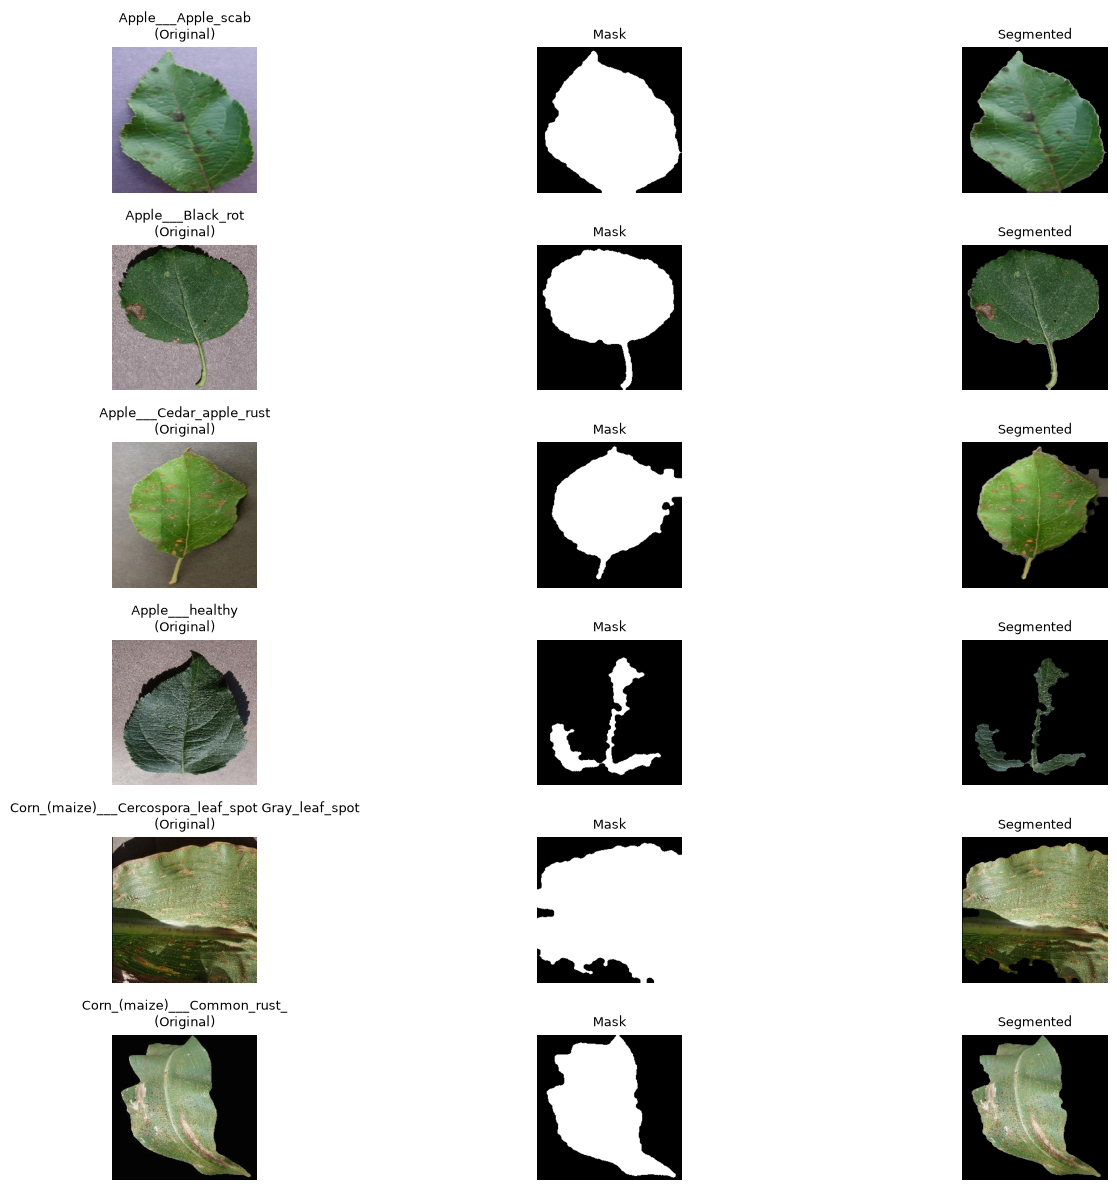

In [7]:
class_folders = sorted([d for d in (SPLIT_ROOT / 'train').iterdir() if d.is_dir()])
sample_images = []

for class_dir in class_folders[:6]:
    images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
    if images:
        img_path = images[0]
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        sample_images.append((class_dir.name, img_rgb, img_path))

fig, axes = plt.subplots(len(sample_images), 3, figsize=(15, 12))

for idx, (class_name, img, img_path) in enumerate(sample_images):
    segmented, mask = segment_leaf_morphological(img)
    
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f'{class_name}\n(Original)', fontsize=9)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(mask, cmap='gray')
    axes[idx, 1].set_title('Mask', fontsize=9)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(segmented)
    axes[idx, 2].set_title('Segmented', fontsize=9)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

## Batch Process All Splits

In [9]:
for split in ['train', 'val', 'test']:
    split_dir = SPLIT_ROOT / split
    output_split_dir = OUTPUT_ROOT / split
    
    for class_dir in split_dir.iterdir():
        if class_dir.is_dir():
            class_name = class_dir.name
            output_class_dir = output_split_dir / class_name
            output_class_dir.mkdir(parents=True, exist_ok=True)
            
            images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
            
            for img_path in tqdm(images, desc=f'{split}/{class_name}'):
                img = cv2.imread(str(img_path))
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                segmented, mask = segment_leaf_morphological(img_rgb)
                
                output_path = output_class_dir / img_path.name
                segmented_bgr = cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR)
                cv2.imwrite(str(output_path), segmented_bgr)

print("Batch processing complete!")

train/Apple___healthy: 100%|██████████| 1607/1607 [00:18<00:00, 87.46it/s]
train/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 100%|██████████| 1348/1348 [00:16<00:00, 82.24it/s]
train/Tomato_Septoria_leaf_spot: 100%|██████████| 1410/1410 [00:23<00:00, 60.07it/s]
train/Tomato_Spider_mites_Two_spotted_spider_mite: 100%|██████████| 1319/1319 [00:21<00:00, 61.08it/s]
val/Apple___healthy: 100%|██████████| 197/197 [00:03<00:00, 64.68it/s]
val/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 100%|██████████| 126/126 [00:01<00:00, 68.38it/s]
test/Apple___healthy: 100%|██████████| 204/204 [00:02<00:00, 73.94it/s]
test/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 100%|██████████| 168/168 [00:02<00:00, 65.82it/s]
test/Tomato__Tomato_YellowLeaf__Curl_Virus: 100%|██████████| 297/297 [00:04<00:00, 68.77it/s]

Batch processing complete!


## Verify Output

In [10]:
split_counts = {}

for split in ['train', 'val', 'test']:
    split_counts[split] = {}
    split_dir = OUTPUT_ROOT / split
    
    for class_dir in split_dir.iterdir():
        if class_dir.is_dir():
            images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
            split_counts[split][class_dir.name] = len(images)

total_morphological = sum(sum(counts.values()) for counts in split_counts.values())

print("\n" + "="*60)
print("MORPHOLOGICAL SEGMENTATION COMPLETE")
print("="*60)
for split in ['train', 'val', 'test']:
    count = sum(split_counts[split].values())
    print(f"{split}: {count} images")

print(f"\nTotal: {total_morphological} segmented images")
print(f"Output directory: {OUTPUT_ROOT}")


MORPHOLOGICAL SEGMENTATION COMPLETE
train: 28627 images
val: 3551 images
test: 3547 images

Total: 35725 segmented images
Output directory: Dataset_Split_Morphological


## Visualize Morphological Results

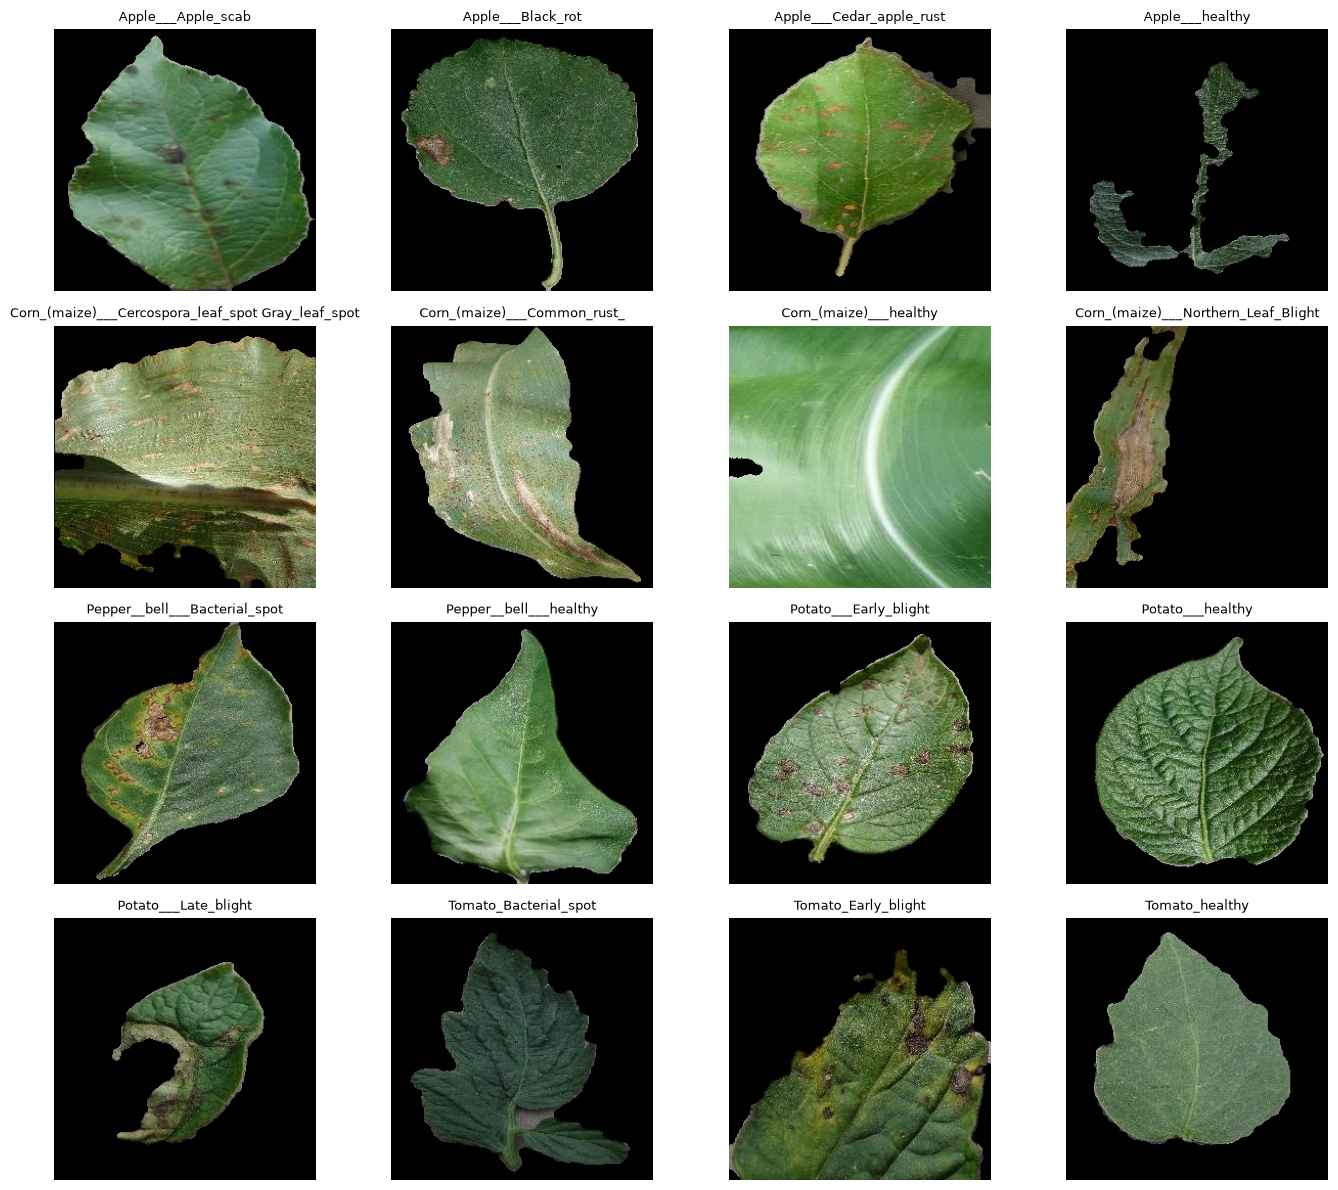

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
axes = axes.flatten()

idx = 0
for class_dir in (OUTPUT_ROOT / 'train').iterdir():
    if idx >= len(axes):
        break
    if class_dir.is_dir():
        images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
        if images:
            img = cv2.imread(str(images[0]))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img_rgb)
            axes[idx].set_title(class_dir.name, fontsize=9)
            axes[idx].axis('off')
            idx += 1

for j in range(idx, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()